In [1]:
import os
import glob
import cv2
import numpy as np
from pathlib import Path

# Paths
BASE_DIR = Path("..").resolve() / "data"
if not BASE_DIR.exists():
    BASE_DIR = Path("data").resolve()

val_images = sorted(glob.glob(str(BASE_DIR / "images" / "images" / "val" / "*.*")))
val_masks  = sorted(glob.glob(str(BASE_DIR / "masks"  / "masks"  / "val" / "*.*")))

def calculate_iou_dice(pred, target):
    """Calculates Intersection-over-Union (IoU) and Dice coefficient."""
    intersection = np.logical_and(pred, target).sum()
    union = np.logical_or(pred, target).sum()
    
    iou = (intersection + 1e-6) / (union + 1e-6)
    dice = (2.0 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)
    return iou, dice

# Evaluate Otsu on validation set (first 200 samples for speed)
ious = []
dices = []

for img_p, msk_p in zip(val_images[:200], val_masks[:200]):
    img = cv2.imread(img_p, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.imread(msk_p, cv2.IMREAD_GRAYSCALE)
    gt_binary = (gt_mask > 127).astype(np.uint8)
    
    # Otsu thresholding: oil is dark, so invert threshold (pixels < T -> 1)
    _, otsu_thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    pred_binary = (otsu_thresh > 0).astype(np.uint8)
    
    iou, dice = calculate_iou_dice(pred_binary, gt_binary)
    ious.append(iou)
    dices.append(dice)

print("=== BASELINE (OTSU THRESHOLDING) RESULTS ===")
print(f"Mean IoU:  {np.mean(ious):.4f}")
print(f"Mean Dice: {np.mean(dices):.4f}")

=== BASELINE (OTSU THRESHOLDING) RESULTS ===
Mean IoU:  0.2416
Mean Dice: 0.3506


In [4]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 1. Resolve Dataset Paths
BASE_DIR = Path("..").resolve() / "data"
if not BASE_DIR.exists():
    BASE_DIR = Path("data").resolve()

print(f"Loading files from: {BASE_DIR}")

train_images = sorted(glob.glob(str(BASE_DIR / "images" / "images" / "train" / "*.*")))
train_masks  = sorted(glob.glob(str(BASE_DIR / "masks"  / "masks"  / "train" / "*.*")))
val_images   = sorted(glob.glob(str(BASE_DIR / "images" / "images" / "val"   / "*.*")))
val_masks    = sorted(glob.glob(str(BASE_DIR / "masks"  / "masks"  / "val"   / "*.*")))

print(f"Train set: {len(train_images)} images, {len(train_masks)} masks")
print(f"Val set:   {len(val_images)} images, {len(val_masks)} masks")

# 2. PyTorch Dataset Definition
class SAROilDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        
        # Binarize mask: 0.0 for clean water, 1.0 for oil spill
        mask = (mask > 127).astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]
        else:
            image = image.astype(np.float32) / 255.0
            image = torch.tensor(image).unsqueeze(0)
            mask = torch.tensor(mask).unsqueeze(0)

        # Ensure mask has shape [1, H, W]
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image, mask

# 3. Augmentations & Normalization
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

# 4. Instantiate Datasets & DataLoaders
BATCH_SIZE = 16

train_dataset = SAROilDataset(train_images, train_masks, transform=train_transform)
val_dataset   = SAROilDataset(val_images, val_masks, transform=val_transform)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,
    pin_memory=True
)

print("\nDataLoaders created successfully!")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Loading files from: /Users/ava/OilSpill_SIH/data
Train set: 6455 images, 6455 masks
Val set:   1615 images, 1615 masks

DataLoaders created successfully!
Train batches: 404 | Val batches: 101


Batch Image Tensor Shape : torch.Size([16, 1, 256, 256])  --> [B, C, H, W]
Batch Mask Tensor Shape  : torch.Size([16, 1, 256, 256])   --> [B, C, H, W]
Image Value Range        : [-1.00, 1.00]
Unique Mask Values       : tensor([0., 1.])


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


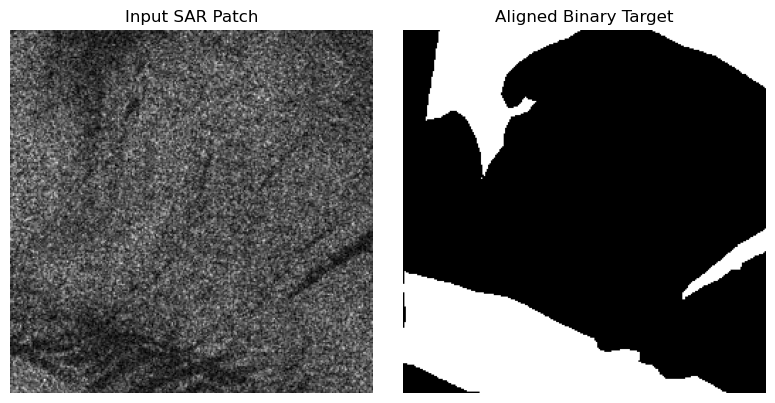

In [5]:
sample_imgs, sample_masks = next(iter(train_loader))

print(f"Batch Image Tensor Shape : {sample_imgs.shape}  --> [B, C, H, W]")
print(f"Batch Mask Tensor Shape  : {sample_masks.shape}   --> [B, C, H, W]")
print(f"Image Value Range        : [{sample_imgs.min():.2f}, {sample_imgs.max():.2f}]")
print(f"Unique Mask Values       : {torch.unique(sample_masks)}")

# Quick visualization of sample 0 in the batch
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(sample_imgs[0, 0].cpu().numpy(), cmap="gray")
ax[0].set_title("Input SAR Patch")
ax[0].axis("off")

ax[1].imshow(sample_masks[0, 0].cpu().numpy(), cmap="gray")
ax[1].set_title("Aligned Binary Target")
ax[1].axis("off")

plt.tight_layout()
plt.show()

In [6]:
pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 31.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 48.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 48.4 MB/s  0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uninstalled click-8.2.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [segmentation-models-pytorch]4/6 [timm]hub]
Note: you may need to restart the kernel to use updated packages.


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        # BCE component (operates on raw unactivated logits)
        bce_loss = self.bce(logits, targets)

        # Dice component (apply sigmoid to convert logits to probabilities)
        probs = torch.sigmoid(logits)
        
        # Flatten batch and spatial dimensions
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)

        intersection = (probs_flat * targets_flat).sum()
        dice_loss = 1.0 - (2.0 * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)

        return self.bce_weight * bce_loss + (1.0 - self.bce_weight) * dice_loss

In [8]:
import segmentation_models_pytorch as smp

# Hardware check: Apple Silicon MPS, NVIDIA CUDA, or CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # Uses Mac M-series GPU acceleration
else:
    device = torch.device("cpu")

print(f"Training on device: {device}")

# Lightweight, fast-training U-Net
model = smp.Unet(
    encoder_name="resnet18",        
    encoder_weights=None,           # Trained from scratch for 1-channel radar backscatter
    in_channels=1,                  # Grayscale SAR amplitude
    classes=1                       # Binary: 1 = oil spill, 0 = sea background
).to(device)

criterion = BCEDiceLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

Training on device: mps


In [9]:
from tqdm import tqdm

num_epochs = 5
best_val_dice = 0.0

for epoch in range(1, num_epochs + 1):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss = train_loss / len(train_loader.dataset)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    val_dices = []
    val_ious = []

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} [Val]"):
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = criterion(logits, masks)
            val_loss += loss.item() * images.size(0)

            # Predictions: threshold probabilities at 0.5
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            # Batch Dice & IoU calculation
            preds_flat = preds.view(preds.size(0), -1)
            masks_flat = masks.view(masks.size(0), -1)
            
            intersection = (preds_flat * masks_flat).sum(dim=1)
            union = (preds_flat + masks_flat).sum(dim=1) - intersection
            
            dice = (2.0 * intersection + 1e-6) / (preds_flat.sum(dim=1) + masks_flat.sum(dim=1) + 1e-6)
            iou = (intersection + 1e-6) / (union + 1e-6)

            val_dices.extend(dice.cpu().numpy())
            val_ious.extend(iou.cpu().numpy())

    val_loss = val_loss / len(val_loader.dataset)
    mean_dice = np.mean(val_dices)
    mean_iou = np.mean(val_ious)

    print(f"\nEpoch {epoch} Summary:")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Val Dice: {mean_dice:.4f} (Baseline: 0.3506) | Val IoU: {mean_iou:.4f} (Baseline: 0.2416)\n")

    # Save best model checkpoint
    if mean_dice > best_val_dice:
        best_val_dice = mean_dice
        torch.save(model.state_dict(), "best_oil_spill_unet.pth")
        print(f"--> Saved new best model checkpoint (Dice: {best_val_dice:.4f})\n")

Epoch 1/5 [Train]:   0%|                                | 0/404 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/5 [Val]: 100%|████████████████████████| 101/101 [00:14<00:00,  7.19it/s]



Epoch 1 Summary:
Train Loss: 0.2901 | Val Loss: 0.2822
Val Dice: 0.7316 (Baseline: 0.3506) | Val IoU: 0.6185 (Baseline: 0.2416)

--> Saved new best model checkpoint (Dice: 0.7316)



Epoch 2/5 [Val]: 100%|████████████████████████| 101/101 [00:15<00:00,  6.57it/s]



Epoch 2 Summary:
Train Loss: 0.2513 | Val Loss: 0.2403
Val Dice: 0.7604 (Baseline: 0.3506) | Val IoU: 0.6509 (Baseline: 0.2416)

--> Saved new best model checkpoint (Dice: 0.7604)



Epoch 3/5 [Val]: 100%|████████████████████████| 101/101 [00:15<00:00,  6.59it/s]



Epoch 3 Summary:
Train Loss: 0.2437 | Val Loss: 0.2892
Val Dice: 0.7281 (Baseline: 0.3506) | Val IoU: 0.6199 (Baseline: 0.2416)



Epoch 4/5 [Val]: 100%|████████████████████████| 101/101 [00:15<00:00,  6.32it/s]



Epoch 4 Summary:
Train Loss: 0.2279 | Val Loss: 0.2526
Val Dice: 0.7483 (Baseline: 0.3506) | Val IoU: 0.6416 (Baseline: 0.2416)



Epoch 5/5 [Val]: 100%|████████████████████████| 101/101 [00:15<00:00,  6.52it/s]


Epoch 5 Summary:
Train Loss: 0.2213 | Val Loss: 0.2495
Val Dice: 0.7329 (Baseline: 0.3506) | Val IoU: 0.6236 (Baseline: 0.2416)



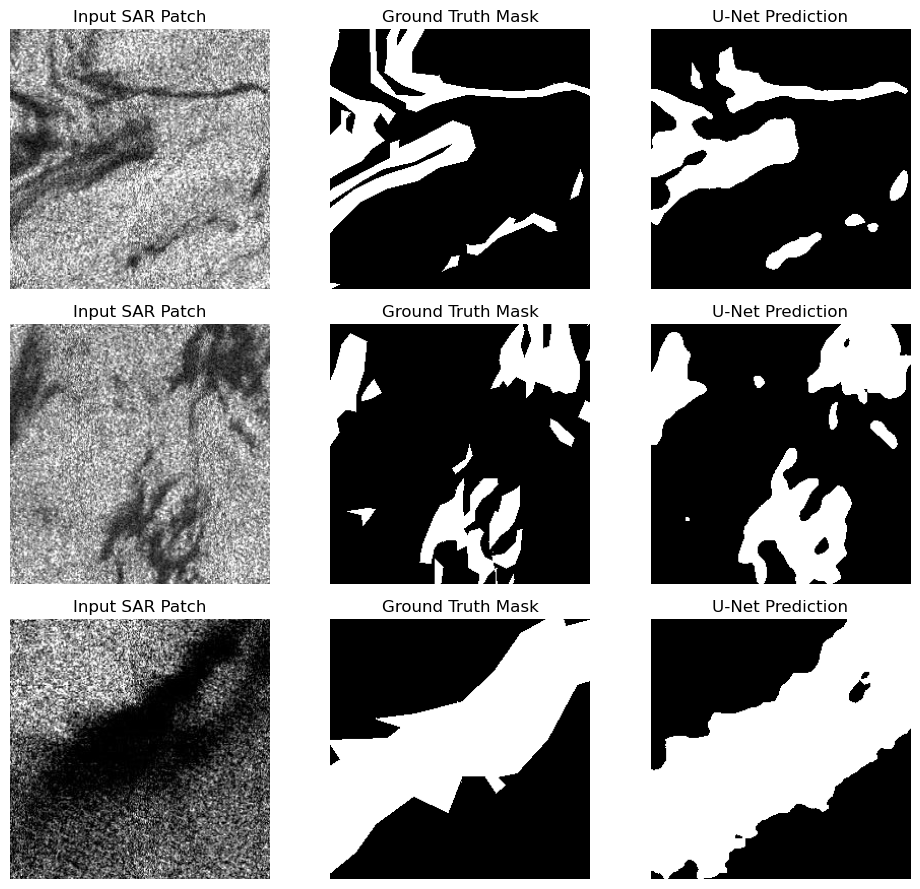

In [10]:
# Load best weights
model.load_state_dict(torch.load("best_oil_spill_unet.pth", map_location=device))
model.eval()

# Pick one validation batch
test_imgs, test_masks = next(iter(val_loader))
with torch.no_grad():
    test_logits = model(test_imgs.to(device))
    test_preds = (torch.sigmoid(test_logits) > 0.5).float().cpu()

# Plot first 3 samples
fig, axes = plt.subplots(3, 3, figsize=(10, 9))
for i in range(3):
    axes[i, 0].imshow(test_imgs[i, 0].numpy(), cmap="gray")
    axes[i, 0].set_title("Input SAR Patch")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(test_masks[i, 0].numpy(), cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(test_preds[i, 0].numpy(), cmap="gray")
    axes[i, 2].set_title("U-Net Prediction")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [11]:
import json
import cv2
import numpy as np
import torch
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

# 1. Device and Model Initialization
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

model.load_state_dict(torch.load("best_oil_spill_unet.pth", map_location=device))
model.eval()

# 2. Define Inference Preprocessor
infer_transform = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

def detect_oil_spill(image_path, threshold=0.5, min_area_pixels=50):
    """
    End-to-end inference function for Member 1 handover.
    
    Returns:
        metadata (dict): Spill detection summary for Member 2.
        pred_mask_uint8 (np.ndarray): 256x256 binary mask (0 or 255).
    """
    raw_img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    h, w = raw_img.shape

    # Preprocessing
    transformed = infer_transform(image=raw_img)
    input_tensor = transformed["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()

    # Binary mask
    binary_mask = (probs > threshold).astype(np.uint8)

    # Connected component analysis to isolate the main spill body
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask)

    spill_detected = False
    confidence = 0.0
    centroid = None
    bbox = None
    spill_area_px = 0

    if num_labels > 1:  # Index 0 is background
        # Find the largest non-background component
        areas = stats[1:, cv2.CC_STAT_AREA]
        largest_idx = 1 + np.argmax(areas)
        spill_area_px = int(stats[largest_idx, cv2.CC_STAT_AREA])

        if spill_area_px >= min_area_pixels:
            spill_detected = True
            # Compute confidence strictly over the spill region
            spill_region = (labels == largest_idx)
            confidence = float(np.mean(probs[spill_region]))

            cx, cy = centroids[largest_idx]
            centroid = {"x": round(float(cx), 2), "y": round(float(cy), 2)}

            x = int(stats[largest_idx, cv2.CC_STAT_LEFT])
            y = int(stats[largest_idx, cv2.CC_STAT_TOP])
            bw = int(stats[largest_idx, cv2.CC_STAT_WIDTH])
            bh = int(stats[largest_idx, cv2.CC_STAT_HEIGHT])
            bbox = {"xmin": x, "ymin": y, "xmax": x + bw, "ymax": y + bh}

    metadata = {
        "source_image": Path(image_path).name,
        "image_dimensions": {"width": w, "height": h},
        "spill_detected": spill_detected,
        "spill_area_pixels": spill_area_px,
        "confidence_score": round(confidence, 4),
        "centroid_pixel": centroid,
        "bounding_box_pixel": bbox,
        "simulated_timestamp_utc": "2026-09-04T11:13:38Z"  # Hook for Member 2's AIS query window
    }

    pred_mask_uint8 = (binary_mask * 255).astype(np.uint8)
    return metadata, pred_mask_uint8

In [12]:
# Create an exports directory
export_dir = Path("exports_for_member2")
export_dir.mkdir(exist_ok=True)

# Run detection on the first validation image
test_sample_path = val_images[0]
meta, out_mask = detect_oil_spill(test_sample_path)

# Save deliverables
mask_save_path = export_dir / "detected_oil_mask.png"
meta_save_path = export_dir / "detection_metadata.json"

cv2.imwrite(str(mask_save_path), out_mask)
with open(meta_save_path, "w") as f:
    json.dump(meta, f, indent=4)

print("=== HANDOVER ARTIFACTS CREATED ===")
print(f"Mask exported to: {mask_save_path}")
print(f"JSON metadata exported to: {meta_save_path}\n")
print(json.dumps(meta, indent=4))

=== HANDOVER ARTIFACTS CREATED ===
Mask exported to: exports_for_member2/detected_oil_mask.png
JSON metadata exported to: exports_for_member2/detection_metadata.json

{
    "source_image": "palsar_0.png",
    "image_dimensions": {
        "width": 256,
        "height": 256
    },
    "spill_detected": true,
    "spill_area_pixels": 8000,
    "confidence_score": 0.876,
    "centroid_pixel": {
        "x": 61.27,
        "y": 120.37
    },
    "bounding_box_pixel": {
        "xmin": 0,
        "ymin": 59,
        "xmax": 146,
        "ymax": 193
    },
    "simulated_timestamp_utc": "2026-09-04T11:13:38Z"
}


In [13]:
pip install geojson

Note: you may need to restart the kernel to use updated packages.


In [15]:
import json
import cv2
import numpy as np
import torch
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# --- 1. MODEL INITIALIZATION ---
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

model.load_state_dict(torch.load("best_oil_spill_unet.pth", map_location=device))
model.eval()

infer_transform = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

# --- 2. COORDINATE TRANSFORM HELPER ---
def pixel_to_geo(x, y, bounds, width=256, height=256):
    """
    Transforms pixel (x, y) to geographic [longitude, latitude].
    bounds: (min_lon, min_lat, max_lon, max_lat)
    """
    min_lon, min_lat, max_lon, max_lat = bounds
    lon = min_lon + (x / width) * (max_lon - min_lon)
    lat = max_lat - (y / height) * (max_lat - min_lat)
    return [round(lon, 6), round(lat, 6)]

# --- 3. CORE INFERENCE & CONVERSION PIPELINE ---
def process_sar_image_for_pipeline(
    image_path, 
    image_id="spill_001",
    output_dir="pipeline_outputs",
    geo_bounds=(72.5000, 18.8000, 72.8500, 19.1500), # Demo: Off Mumbai coast (Arabian Sea)
    threshold=0.5,
    min_area_px=40
):
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    # 1. Read SAR Image
    raw_img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    h, w = raw_img.shape

    # 2. Run Inference
    tensor_input = infer_transform(image=raw_img)["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor_input)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()

    binary_mask = (probs > threshold).astype(np.uint8)

    # 3. Contour & Morphological Extraction
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    detected = False
    confidence = 0.0
    bbox_result = []
    geojson_features = []

    # Filter out minor speckle noise
    valid_contours = [c for c in contours if cv2.contourArea(c) >= min_area_px]

    if len(valid_contours) > 0:
        detected = True

        # Find largest spill contour for primary bbox & mean confidence
        largest_contour = max(valid_contours, key=cv2.contourArea)
        x, y, bw, bh = cv2.boundingRect(largest_contour)
        
        # Team format: [xmin, ymin, xmax, ymax]
        bbox_result = [int(x), int(y), int(x + bw), int(y + bh)]

        # Calculate confidence specifically within detected oil zones
        spill_pixels = (binary_mask == 1)
        confidence = round(float(np.mean(probs[spill_pixels])), 2)

        # Convert contours into GeoJSON Polygons
        for c in valid_contours:
            # Approximate polygon to reduce payload size while keeping shape
            epsilon = 0.005 * cv2.arcLength(c, True)
            approx = cv2.approxPolyDP(c, epsilon, True)
            
            geo_polygon = []
            for pt in approx:
                px, py = pt[0][0], pt[0][1]
                geo_polygon.append(pixel_to_geo(px, py, geo_bounds, w, h))
            
            # Close the GeoJSON LinearRing
            if len(geo_polygon) >= 3:
                geo_polygon.append(geo_polygon[0])

                geojson_features.append({
                    "type": "Feature",
                    "properties": {
                        "spill_id": image_id,
                        "area_pixels": int(cv2.contourArea(c)),
                        "confidence": confidence
                    },
                    "geometry": {
                        "type": "Polygon",
                        "coordinates": [geo_polygon]
                    }
                })

    # 4. Save Binary Mask
    mask_filename = f"{image_id}_mask.png"
    mask_filepath = out_path / mask_filename
    cv2.imwrite(str(mask_filepath), binary_mask * 255)

    # 5. Save GeoJSON FeatureCollection
    geojson_payload = {
        "type": "FeatureCollection",
        "features": geojson_features
    }
    geojson_filename = f"{image_id}_geometry.geojson"
    geojson_filepath = out_path / geojson_filename
    with open(geojson_filepath, "w") as f:
        json.dump(geojson_payload, f, indent=2)

    # 6. Team API JSON Contract
    api_contract = {
        "image_id": image_id,
        "detected": detected,
        "confidence": confidence,
        "mask_path": str(mask_filepath),
        "bbox": bbox_result,
        "geojson_path": str(geojson_filepath)
    }

    meta_filename = f"{image_id}_meta.json"
    with open(out_path / meta_filename, "w") as f:
        json.dump(api_contract, f, indent=2)

    return api_contract, geojson_payload

In [16]:
# Execute detection on a validation image
api_result, geojson_result = process_sar_image_for_pipeline(
    image_path=val_images[0],
    image_id="spill_001"
)

print("=== EXACT TEAM API OUTPUT ===")
print(json.dumps(api_result, indent=2))

print("\n=== GENERATED GEOJSON SAMPLE ===")
print(json.dumps(geojson_result, indent=2)[:500] + "\n... [truncated]")

=== EXACT TEAM API OUTPUT ===
{
  "image_id": "spill_001",
  "detected": true,
  "confidence": 0.86,
  "mask_path": "pipeline_outputs/spill_001_mask.png",
  "bbox": [
    0,
    59,
    146,
    193
  ],
  "geojson_path": "pipeline_outputs/spill_001_geometry.geojson"
}

=== GENERATED GEOJSON SAMPLE ===
{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {
        "spill_id": "spill_001",
        "area_pixels": 724,
        "confidence": 0.86
      },
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [
              72.72832,
              18.873828
            ],
            [
              72.724219,
              18.876562
            ],
            [
              72.721484,
              18.876562
... [truncated]
